In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping


warnings.filterwarnings('ignore', category = UserWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

plt.rc('figure', autolayout = True)
plt.rc('axes', labelweight = 'bold', labelsize = 'large', titleweight = 'bold', titlesize = 14, titlepad = 10)
plt.style.use('classic')

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/zahemen9900/YouTube-Analytics-App/main/YouTube%20Data%20EDA/yt_cluster_data.csv")
df.head()

,Username,Categories,Subscribers,Country,Visits,Likes,Continent,Cluster
0,KidsDianaShow,"Animation, Toys",113500000,Unknown,3900000.000,12400,Unknown,3
1,PewDiePie,"Movies, Video Games",111500000,United States,2400000.000,197300,North America,3
2,LikeNastyaofficial,Toys,107500000,Unknown,2600000.000,28000,Unknown,3
3,VladandNiki,"Animation, Toys",101400000,Unknown,4100000.000,22100,Unknown,3
4,zeemusiccompany,Music and Dance,99700000,India,74300.000,2600,Asia,3


In [3]:
yt_df = pd.read_csv("https://raw.githubusercontent.com/zahemen9900/YouTube-Analytics-App/main/YouTube%20Data%20EDA/yt_cluster_data.csv")
yt_df = yt_df.drop('Cluster', axis = 1)
yt_df.head()

,Username,Categories,Subscribers,Country,Visits,Likes,Continent
0,KidsDianaShow,"Animation, Toys",113500000,Unknown,3900000.000,12400,Unknown
1,PewDiePie,"Movies, Video Games",111500000,United States,2400000.000,197300,North America
2,LikeNastyaofficial,Toys,107500000,Unknown,2600000.000,28000,Unknown
3,VladandNiki,"Animation, Toys",101400000,Unknown,4100000.000,22100,Unknown
4,zeemusiccompany,Music and Dance,99700000,India,74300.000,2600,Asia


In [4]:
yt_df.iloc[:300, :].to_csv("yt_df.csv", index = False)


# Creating a Unique Metric to assess Channel performance
---

Since there's no actual metric to measure a channel's performance based on the metrics available, we create a custom metric known as the _**Composite Performance Metric (CPM)**_
The Composite Performance Metric (CPM) can be designed to incorporate the different aspects of a channel's performance. Here's one way to create it:

$$
\text{CPM} = 𝛼 × \text{Subscribers_normalized} + 𝛽 × \text{Visits_normalized }+ 𝛾 × \text{Likes_normalized}
$$

Where:

- 𝛼, 𝛽 and  𝛾 are weights assigned to subscribers, visits, and likes, respectively.
- The normalization ensures that the different metrics are on a comparable scale.


## Steps for Normalizing the Metrics
---

Steps to Create CPM
- Normalize the Metrics: Use min-max normalization to scale subscribers, visits, and likes between 0 and 1.
A- ssign Weights: Decide on the weights (𝛼, 𝛽, 𝛾) based on the importance of each metric. For example, if you believe visits are the most crucial, you might give it a higher weight.
- Calculate CPM: Compute the CPM using the normalized values and weights.

We will assume the following importances for the CPM:
- $\alpha$ = 0.3 (subscribers)
- $\beta$ = 0.5 (visits)
- $\gamma$ = 0.2 (likes)

In [5]:

# Select the relevant columns
metrics = yt_df[['Subscribers', 'Visits', 'Likes']]

# Apply min-max normalization
scaler = MinMaxScaler()
normalized_metrics = scaler.fit_transform(metrics)

# Create a new DataFrame with normalized values
normalized_df = pd.DataFrame(normalized_metrics, columns=['Subscribers_normalized', 'Visits_normalized', 'Likes_normalized'])

# Display the normalized values
normalized_df.head()


,Subscribers_normalized,Visits_normalized,Likes_normalized
0,1.000,0.181,0.009
1,0.980,0.112,0.141
2,0.941,0.121,0.020
3,0.881,0.191,0.016
4,0.864,0.003,0.002


In [6]:
alpha, beta, gamma = 0.3, 0.5, 0.2

# Calculate the CPM
normalized_df['CPM'] = (alpha * normalized_df['Subscribers_normalized'] +
                        beta * normalized_df['Visits_normalized'] +
                        gamma * normalized_df['Likes_normalized'])

# Add the CPM to the original dataframe
yt_df['CPM'] = normalized_df['CPM']

# Display the DataFrame with the new CPM column
yt_df.head()

,Username,Categories,Subscribers,Country,Visits,Likes,Continent,CPM
0,KidsDianaShow,"Animation, Toys",113500000,Unknown,3900000.000,12400,Unknown,0.392
1,PewDiePie,"Movies, Video Games",111500000,United States,2400000.000,197300,North America,0.378
2,LikeNastyaofficial,Toys,107500000,Unknown,2600000.000,28000,Unknown,0.347
3,VladandNiki,"Animation, Toys",101400000,Unknown,4100000.000,22100,Unknown,0.363
4,zeemusiccompany,Music and Dance,99700000,India,74300.000,2600,Asia,0.261


### Training a Tokenizer on the User Names
---
The name used on a channel would usually tend to influence other metrics such as

In [7]:
channel_names = yt_df['Username'].to_list()

tokenizer = Tokenizer(num_words = 1000, oov_token = '<OOV>')
tokenizer.fit_on_texts(channel_names)

In [8]:
#convert text to sequences
#Since we are only dealing with channel names, the maxlen parameter should be small

sequences = tokenizer.texts_to_sequences(channel_names)
padded_sequences = pad_sequences(
    sequences, maxlen = 3, padding = 'post', truncating = 'post'
)

sequences_df = pd.DataFrame(padded_sequences, columns = [f'token_{i}' for i in range(padded_sequences.shape[1])])
sequences_df.head()

,token_0,token_1,token_2
0,18,0,0
1,19,0,0
2,20,0,0
3,21,0,0
4,22,0,0


In [9]:
for col in sequences_df.columns:
  print(sequences_df[col].nunique())

954
47
5


In [10]:
yt_df['Categories'].isnull().sum()

305

In [11]:
yt_df.select_dtypes(include = ['number']).columns

Index(['Subscribers', 'Visits', 'Likes', 'CPM'], dtype='object')

In [12]:
numeric_features = yt_df.select_dtypes(include = ['number'])

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

# Handle missing values in 'Categories'
yt_df['Categories'] = yt_df['Categories'].fillna('Unknown')

X = yt_df.copy()
# y = X.pop('CPM')


In [14]:
X.columns

Index(['Username', 'Categories', 'Subscribers', 'Country', 'Visits', 'Likes',
       'Continent', 'CPM'],
      dtype='object')

In [15]:
from sklearn.cluster import KMeans

numerical_features = ['Subscribers', 'Visits', 'Likes', 'CPM']
categorical_features = ['Categories', 'Country', 'Continent']
col_names = numerical_features + categorical_features


#create clusters based on features
def get_kmeans_rankings(X_, cols = col_names, cols_to_use = numerical_features, n_clusters=5, subset = True):
    if not isinstance(X_, pd.DataFrame):
        X = pd.DataFrame(X_.copy(), columns = cols)
    else:
        X = X_.copy()

    # if subset:
    #     X_sub = X[cols_to_use].copy()
    #     X.drop(cols_to_use, axis = 1, inplace = True)

        # Perform K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, n_init = 10, random_state=42)
    if subset:
        clusters = kmeans.fit_predict(X[cols_to_use])
    else:
        clusters = kmeans.fit_predict(X)

    # Add cluster labels to the original DataFrame
    X['clusters'] = clusters

    return X


#creating pipeline to transform features

col_transformer = ColumnTransformer([
    ('scaler', MinMaxScaler(), numerical_features),
    ('encoder', OrdinalEncoder(), categorical_features)
])

pipeline = Pipeline([
    ('column_transformer', col_transformer),
])


X_p = pipeline.fit_transform(X)
X_p = get_kmeans_rankings(X_p)

In [16]:
X_p.head()

,Subscribers,Visits,Likes,CPM,Categories,Country,Continent,clusters
0,1.000,0.181,0.009,0.603,6.000,28.000,5.000,1
1,0.980,0.112,0.141,0.580,29.000,27.000,3.000,1
2,0.941,0.121,0.020,0.532,38.000,28.000,5.000,1
3,0.881,0.191,0.016,0.557,6.000,28.000,5.000,1
4,0.864,0.003,0.002,0.401,30.000,9.000,1.000,1


In [17]:
X['clusters'] = X_p['clusters'].copy()

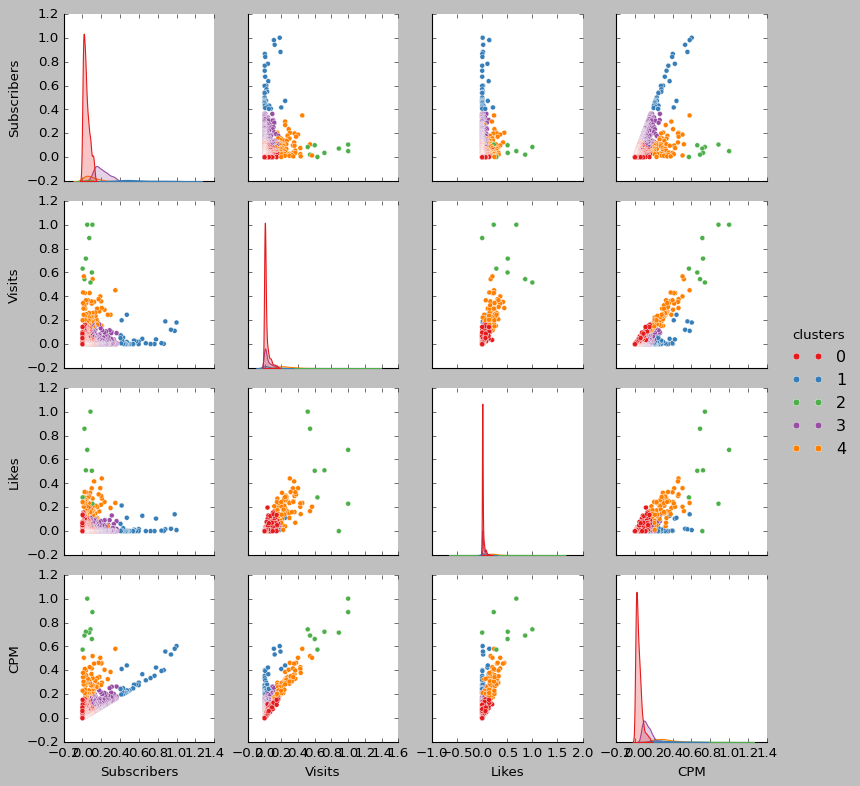

In [26]:
sns.pairplot(X_p, vars = ['Subscribers', 'Visits', 'Likes', 'CPM'], diag_kind = 'kde', hue = 'clusters', palette = 'Set1');

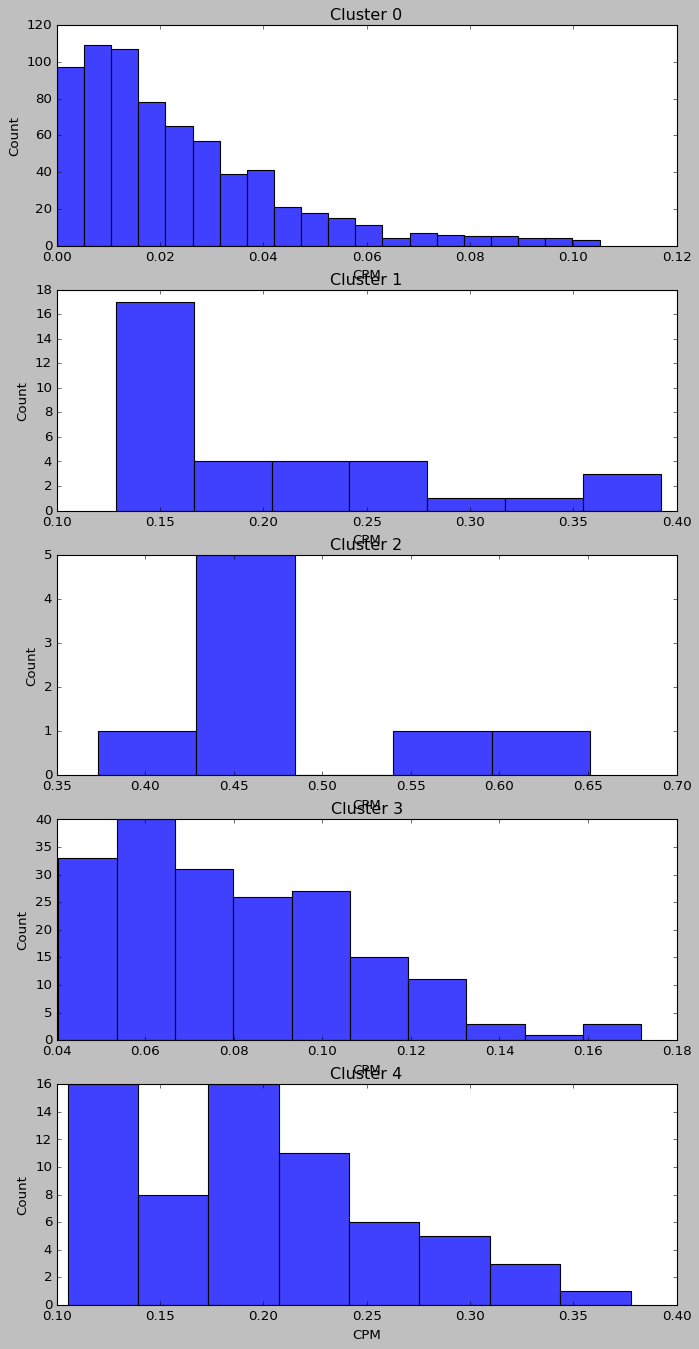

In [40]:
fig, axes = plt.subplots(5, 1, figsize = (10, 20))
for i, ax in enumerate(axes.flatten()):
    sns.histplot(X.loc[X['clusters'] == i, 'CPM'], ax = ax)
    ax.set_title(f'Cluster {i}')
plt.show()

In [24]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

def get_hierarchical_clusters(X_, n_clusters=5, cols = col_names, cols_to_use = numerical_features, method='ward'):
    if not isinstance(X_, pd.DataFrame):
        X = pd.DataFrame(X_.copy(), columns = cols)
    else:
        X = X_.copy()

    # Perform hierarchical clustering
    Z = linkage(X[cols_to_use], method=method)

    # Get cluster labels
    clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
    print(clusters.shape)
    X['clusters_hier'] = clusters

    return X, Z

hier_df, Z = get_hierarchical_clusters(X_p.drop('clusters', axis = 1))

(994,)


In [19]:
display(X_p.head())

,Subscribers,Visits,Likes,CPM,Categories,Country,Continent,clusters
0,1.000,0.181,0.009,0.603,6.000,28.000,5.000,2
1,0.980,0.112,0.141,0.580,29.000,27.000,3.000,2
2,0.941,0.121,0.020,0.532,38.000,28.000,5.000,2
3,0.881,0.191,0.016,0.557,6.000,28.000,5.000,2
4,0.864,0.003,0.002,0.401,30.000,9.000,1.000,2


In [27]:
X.head()

,Username,Categories,Subscribers,Country,Visits,Likes,Continent,CPM,clusters
0,KidsDianaShow,"Animation, Toys",113500000,Unknown,3900000.000,12400,Unknown,0.392,1
1,PewDiePie,"Movies, Video Games",111500000,United States,2400000.000,197300,North America,0.378,1
2,LikeNastyaofficial,Toys,107500000,Unknown,2600000.000,28000,Unknown,0.347,1
3,VladandNiki,"Animation, Toys",101400000,Unknown,4100000.000,22100,Unknown,0.363,1
4,zeemusiccompany,Music and Dance,99700000,India,74300.000,2600,Asia,0.261,1


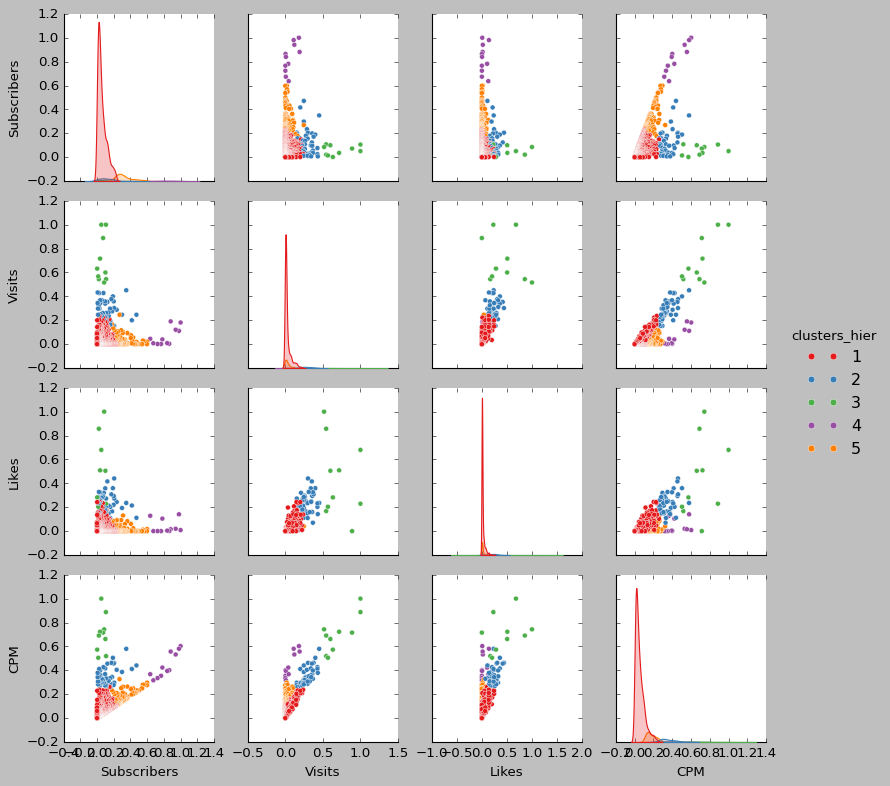

In [25]:
# X['clusters_hier'] = hier_df['clusters_hier'].copy()
sns.pairplot(hier_df, vars = ['Subscribers', 'Visits', 'Likes', 'CPM'], hue = 'clusters_hier', palette = 'Set1');

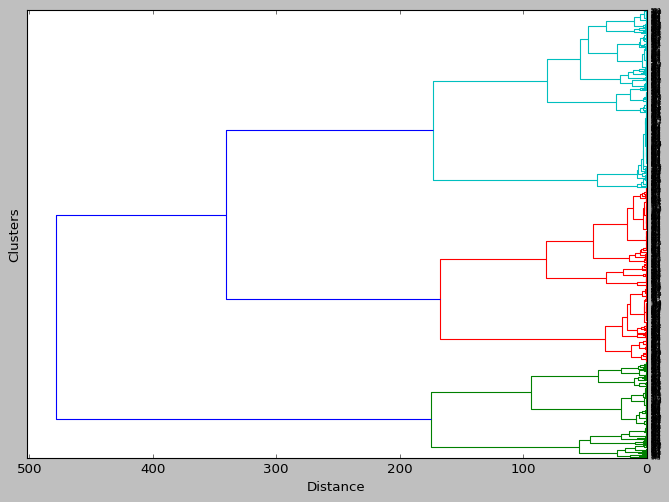

In [21]:
def plot_dendrogram(Z):
    plt.figure(figsize=(10, 7))
    dendrogram(Z, orientation = 'left')
    plt.xlabel('Distance')
    plt.ylabel('Clusters')
    plt.show()

# Plot dendrogram for hierarchical clustering
plot_dendrogram(Z)

In [43]:
X.to_csv("yt_data_final.csv", index = False) #Export to csv for reproducibility

# Building the Model
---

In [47]:
#creating pipeline to transform features

# numerical_features = ['Subscribers', 'Visits', 'Likes']
# categorical_features = ['Categories', 'Country', 'Continent']

# col_transformer = ColumnTransformer([
#     ('scaler', MinMaxScaler(), numerical_features),
#     ('encoder', OrdinalEncoder(), categorical_features)
# ])

# pipeline = Pipeline([
#     ('column_transformer', col_transformer),
# ])

# X_p = pipeline.fit_transform(X)


In [48]:
channel_names = yt_df['Username'].to_list()

tokenizer = Tokenizer(num_words = 1000, oov_token = '<OOV>')
tokenizer.fit_on_texts(channel_names)

In [49]:
#convert text to sequences
#Since we are only dealing with channel names, the maxlen parameter should be small

sequences = tokenizer.texts_to_sequences(channel_names)
padded_sequences = pad_sequences(
    sequences, maxlen = 3, padding = 'post', truncating = 'post'
)

sequences_df = pd.DataFrame(padded_sequences, columns = [f'token_{i}' for i in range(padded_sequences.shape[1])])
sequences_df.head()

,token_0,token_1,token_2
0,18,0,0
1,19,0,0
2,20,0,0
3,21,0,0
4,22,0,0


In [50]:
X_p.head()

,Subscribers,Visits,Likes,CPM,Categories,Country,Continent,clusters
0,1.000,0.181,0.009,0.603,6.000,28.000,5.000,1
1,0.980,0.112,0.141,0.580,29.000,27.000,3.000,1
2,0.941,0.121,0.020,0.532,38.000,28.000,5.000,1
3,0.881,0.191,0.016,0.557,6.000,28.000,5.000,1
4,0.864,0.003,0.002,0.401,30.000,9.000,1.000,1


In [51]:
X_nn = X_p.copy()
y = X_nn.pop('clusters')
y = y.astype(np.int16)
y.value_counts()

clusters
0    696
3    190
4     66
1     34
2      8
Name: count, dtype: int64

In [52]:
text_model = Sequential([
    Embedding(input_dim=1000, output_dim=64, input_length=3),
    LSTM(32)
])

# Define the Sequential model for other features
other_model = Sequential([
    Flatten(input_shape=(X_nn.shape[1],))
])

# Define inputs
text_input = Input(shape=(3,), name='text_input')
other_input = Input(shape=(X_nn.shape[1],), name='other_input')

# Get outputs from Sequential models
text_output = text_model(text_input)
other_output = other_model(other_input)

# Concatenate both outputs
concatenated = Concatenate()([text_output, other_output])

# Add dense layers
dense_1 = Dense(64, activation='relu')(concatenated)
dense_2 = Dense(32, activation='relu')(dense_1)
dense_3 = Dense(16, activation = 'relu')(dense_2)
output = Dense(5, activation='softmax')(dense_3)

# Build the model
model = Model(inputs=[text_input, other_input], outputs=output)

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

stop_early = EarlyStopping(
    min_delta = 0.0001,
    patience = 3,
    restore_best_weights = True

)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text_input (InputLayer)     [(None, 3)]                  0         []                            
                                                                                                  
 other_input (InputLayer)    [(None, 7)]                  0         []                            
                                                                                                  
 sequential (Sequential)     (None, 32)                   76416     ['text_input[0][0]']          
                                                                                                  
 sequential_1 (Sequential)   (None, 7)                    0         ['other_input[0][0]']         
                                                                                              

In [53]:
X_nn.columns

Index(['Subscribers', 'Visits', 'Likes', 'CPM', 'Categories', 'Country',
       'Continent'],
      dtype='object')

In [54]:
y.head(10)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: clusters, dtype: int16

In [55]:

def map_features(text, other, label):
    return {'text_input': text, 'other_input': other}, label

dataset = tf.data.Dataset.from_tensor_slices((padded_sequences, X_nn, y))
dataset = dataset.map(map_features)

# Shuffle, batch, and split the dataset
batch_size = 32
dataset = dataset.shuffle(buffer_size=len(y)).batch(batch_size)
train_size = int(0.8 * len(dataset))
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

In [56]:
model.fit(
    train_dataset,
    epochs= 15,
    validation_data=val_dataset,
    callbacks=[stop_early],
    use_multiprocessing=True,
    workers=4
)

Epoch 1/15
25/25 [==============================] - 4s 35ms/step - loss: 1.0710 - accuracy: 0.6263 - val_loss: 0.9718 - val_accuracy: 0.6701
Epoch 2/15
25/25 [==============================] - 0s 9ms/step - loss: 0.9722 - accuracy: 0.6913 - val_loss: 0.9424 - val_accuracy: 0.6959
Epoch 3/15
25/25 [==============================] - 0s 10ms/step - loss: 0.9168 - accuracy: 0.7025 - val_loss: 0.9151 - val_accuracy: 0.6959
Epoch 4/15
25/25 [==============================] - 0s 9ms/step - loss: 0.9062 - accuracy: 0.7100 - val_loss: 0.8186 - val_accuracy: 0.7165
Epoch 5/15
25/25 [==============================] - 0s 9ms/step - loss: 0.9032 - accuracy: 0.6988 - val_loss: 0.8076 - val_accuracy: 0.7165
Epoch 6/15
25/25 [==============================] - 0s 9ms/step - loss: 0.7796 - accuracy: 0.7013 - val_loss: 0.5087 - val_accuracy: 0.7320
Epoch 7/15
25/25 [==============================] - 0s 10ms/step - loss: 0.4203 - accuracy: 0.8462 - val_loss: 0.3496 - val_accuracy: 0.8763
Epoch 8/15
25/25 

In [57]:
history_df = pd.DataFrame(_.history)
history_df.head()

,loss,accuracy,val_loss,val_accuracy
0,1.071,0.626,0.972,0.670
1,0.972,0.691,0.942,0.696
2,0.917,0.702,0.915,0.696
3,0.906,0.710,0.819,0.716
4,0.903,0.699,0.808,0.716


Minimum validation loss: 0.096
Max Accuracy: 0.969


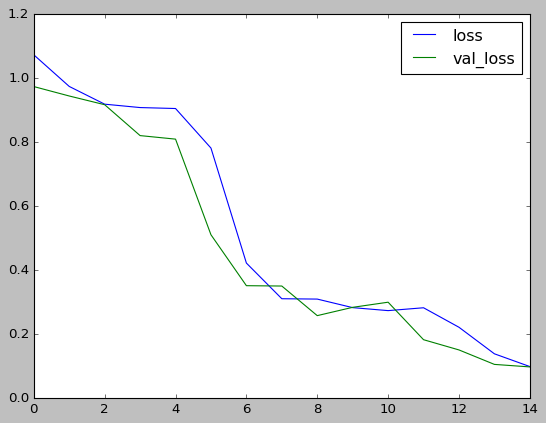

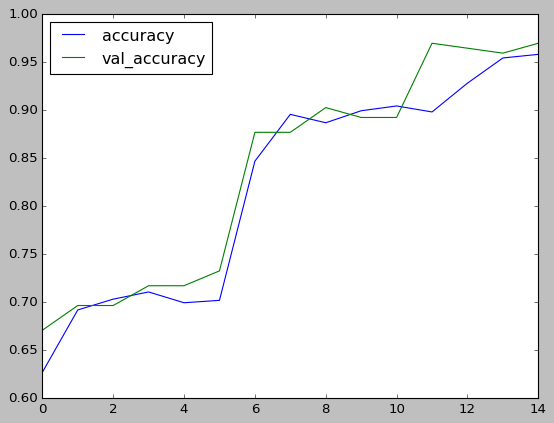

In [58]:
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot();
print(f"Minimum validation loss: {history_df['val_loss'].min():.3f}")
print(f"Max Accuracy: {history_df['val_accuracy'].max():.3f}")

In [59]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Assuming model and tokenizer are already defined and trained

# Example input data
example_channel_names = ['SampleChannel1', 'SampleChannel2']
example_features = np.array([[0.5, 1.2, 0.3, 0.7, 1.0, 0.5, .2], [0.5, 1.2, 0.3, 0.7, 1.0, 0.5, .2]])  # Example features



example_sequences = tokenizer.texts_to_sequences(example_channel_names)
example_padded_sequences = pad_sequences(example_sequences, maxlen=3, padding='post', truncating='post')

# Make predictions
predictions = model.predict([example_padded_sequences, example_features])

# Process predictions for classification
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes)


1/1 [==============================] - 1s 500ms/step
[0 0]


In [60]:

def save_objects(pipeline, cpm_scaler, model, tokenizer, c = 3):
    """
    Function to save the objects for inferencing, and checks if they already exist before saving them
    """
    PATH = os.getcwd()

    if not os.path.exists(
        os.path.join(PATH, 'yt_pipeline.joblib')
    ):
        joblib.dump(pipeline, 'yt_pipeline.joblib')

    if not os.path.exists(
        os.path.join(PATH, 'cpm_scaler.joblib')
    ):
        joblib.dump(cpm_scaler, 'cpm_scaler.joblib')

    if not os.path.exists(
        os.path.join(PATH, 'yt_model.joblib')
    ):
        joblib.dump(model, 'yt_model.joblib', compress=c)

    if not os.path.exists(
        os.path.join(PATH, 'yt_tokenizer.joblib')
    ):
        joblib.dump(tokenizer, 'yt_tokenizer.joblib', compress=c)
    return

save_objects(pipeline, scaler, model, tokenizer)

In [61]:
yt_df.join(y).head()

,Username,Categories,Subscribers,Country,Visits,Likes,Continent,CPM,clusters
0,KidsDianaShow,"Animation, Toys",113500000,Unknown,3900000.000,12400,Unknown,0.392,1
1,PewDiePie,"Movies, Video Games",111500000,United States,2400000.000,197300,North America,0.378,1
2,LikeNastyaofficial,Toys,107500000,Unknown,2600000.000,28000,Unknown,0.347,1
3,VladandNiki,"Animation, Toys",101400000,Unknown,4100000.000,22100,Unknown,0.363,1
4,zeemusiccompany,Music and Dance,99700000,India,74300.000,2600,Asia,0.261,1


In [62]:
import os
import joblib

def load_objects(folder_name = ''):
    """
    Function to load the objects for inferencing.
    """
    PATH = os.getcwd()
    if len(folder_name) < 1:
        pipeline_path = os.path.join(PATH, 'yt_pipeline.joblib')
        cpm_scaler_path = os.path.join(PATH, 'cpm_scaler.joblib')
        model_path = os.path.join(PATH, 'yt_model.joblib')
        tokenizer_path = os.path.join(PATH, 'yt_tokenizer.joblib')
    else:
        pipeline_path = os.path.join(PATH, f'{folder_name}/yt_pipeline.joblib')
        cpm_scaler_path = os.path.join(PATH, f'{folder_name}/cpm_scaler.joblib')
        model_path = os.path.join(PATH, f'{folder_name}/yt_model.joblib')
        tokenizer_path = os.path.join(PATH, f'{folder_name}/yt_tokenizer.joblib')

    if os.path.exists(pipeline_path):
        pipeline = joblib.load(pipeline_path)
    else:
        pipeline = None
        print(f"{pipeline_path} does not exist.")

    if os.path.exists(cpm_scaler_path):
        cpm_scaler = joblib.load(cpm_scaler_path)
    else:
        cpm_scaler = None
        print(f"{cpm_scaler_path} does not exist.")

    if os.path.exists(model_path):
        model = joblib.load(model_path)
    else:
        model = None
        print(f"{model_path} does not exist.")

    if os.path.exists(tokenizer_path):
        tokenizer = joblib.load(tokenizer_path)
    else:
        tokenizer = None
        print(f"{tokenizer_path} does not exist.")

    return pipeline, cpm_scaler, model, tokenizer

# Usage example
pipeline_l, cpm_scaler_l, model_l, tokenizer_l = load_objects()


In [63]:
username = "Zahemen's Tech Vids"

user_input = {
    'Categories': 'Science and Technology',
    'Subscribers': 25_000,
    'Country': 'India',
    'Visits': 2_529_625,
    'Likes': 124000,
    'Continent': 'Asia',
    'CPM': None
}

user_input['CPM'] = alpha * user_input['Subscribers'] + \
                        beta * user_input['Visits'] +  \
                        gamma * user_input['Likes']

user_input_df = pd.DataFrame(user_input, index = [0])


metrics = user_input_df[['Subscribers', 'Visits', 'Likes']]

# Apply min-max normalization
normalized_metrics = scaler.transform(metrics)

user_input_features = pipeline.transform(user_input_df)

username_sequence = tokenizer.texts_to_sequences([username])
user_padded_sequence = pad_sequences(username_sequence, maxlen=3, padding='post', truncating='post')

# Make predictions
predictions = model.predict([user_padded_sequence, user_input_features])

# Process predictions for classification
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes)

1/1 [==============================] - 0s 32ms/step
[4]


In [64]:
alpha, beta, gamma = 0.3, 0.5, 0.2

# Example username and user input
username = "Zahemen's Tech Vids"

user_input = {
    'Categories': 'Science and Technology',
    'Subscribers': 25000,
    'Country': 'India',
    'Visits': 2529625,
    'Likes': 124000,
    'Continent': 'Asia',
}

# Compute CPM

# Convert user_input to DataFrame
user_input_df = pd.DataFrame([user_input])

user_metrics = scaler.transform(user_input_df[['Subscribers', 'Visits', 'Likes']])

user_metrics_df = pd.DataFrame(user_metrics, columns=['Subscribers_normalized', 'Visits_normalized', 'Likes_normalized'])

# Add the CPM to the original dataframe
user_input_df['CPM'] = alpha * user_metrics_df['Subscribers_normalized'] + \
                    beta * user_metrics_df['Visits_normalized'] + \
                    gamma * user_metrics_df['Likes_normalized']

display(user_input_df.head())
user_input_features = pipeline.transform(user_input_df)


username_sequence = tokenizer.texts_to_sequences([username])
user_padded_sequence = pad_sequences(username_sequence, maxlen=3, padding='post', truncating='post')

# Make predictions
predictions = model.predict([user_padded_sequence, user_input_features])

# Process predictions for classification
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes)


,Categories,Subscribers,Country,Visits,Likes,Continent,CPM
0,Science and Technology,25000,India,2529625,124000,Asia,0.042


1/1 [==============================] - 0s 26ms/step
[0]


In [65]:

def generate_predictions(user_input: dict, model, pipeline, scaler, tokenizer, alpha = 0.3, beta = 0.5, gamma = 0.2):
    """
    Function to generate predictions for a given user input
    """
    user_input_df = pd.DataFrame([user_input])

    user_metrics = scaler.transform(user_input_df[['Subscribers', 'Visits', 'Likes']])
    user_metrics_df = pd.DataFrame(user_metrics, columns=['Subscribers_normalized', 'Visits_normalized', 'Likes_normalized'])

    user_input_df['CPM'] = alpha * user_metrics_df['Subscribers_normalized'] + \
                        beta * user_metrics_df['Visits_normalized'] + \
                        gamma * user_metrics_df['Likes_normalized']

    user_input_features = pipeline.transform(user_input_df.drop('Username', axis = 1))

    display(user_input_df.head())

    username_sequence = tokenizer.texts_to_sequences([user_input['Username']])
    user_padded_sequence = pad_sequences(username_sequence, maxlen = 3, padding = 'post', truncating = 'post')

    # Make predictions
    predictions = model.predict([user_padded_sequence, user_input_features])

    # Process predictions for classification
    predicted_classes = np.argmax(predictions, axis=1)

    return predicted_classes[0]

In [66]:
username = "Zahemen's Tech Vids"

user_input = {
    'Username': username,
    'Categories': 'Science and Technology',
    'Subscribers': 25000,
    'Country': 'India',
    'Visits': 2529625,
    'Likes': 124000,
    'Continent': 'Asia',
}


predictions = generate_predictions(user_input, model_l, pipeline_l, cpm_scaler_l, tokenizer_l)
print("Your predicted category is {}".format(predictions))

,Username,Categories,Subscribers,Country,Visits,Likes,Continent,CPM
0,Zahemen's Tech Vids,Science and Technology,25000,India,2529625,124000,Asia,0.042


1/1 [==============================] - 1s 548ms/step
Your predicted category is 0


In [67]:
!pip install transformers

In [68]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

def reword_recommendation(static_recommendation):
    model_name = "gpt2-medium"
    tokenizer = GPT2Tokenizer.from_pretrained(model_name)
    model = GPT2LMHeadModel.from_pretrained(model_name)

    # Encode the input
    input_ids = tokenizer.encode(static_recommendation, return_tensors='pt')

    # Explicitly set the pad_token_id
    tokenizer.pad_token = tokenizer.eos_token

    # Create an attention mask
    attention_mask = input_ids.ne(tokenizer.pad_token_id).long()

    # Generate the output with adjusted parameters for diversity
    output = model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_length=1000,          # Increased length for more detailed output
        num_return_sequences=1,
        no_repeat_ngram_size=2,
        pad_token_id=tokenizer.eos_token_id,
        temperature=0.7,        # Adjust temperature for creativity
        top_p=0.9,              # Use top_p for diverse output
        top_k=50                # Limit the number of highest probability vocabulary tokens
    )

    # Decode the generated text
    reworded_text = tokenizer.decode(output[0], skip_special_tokens=True)

    # Post-process the output to ensure structure
    # You might need additional logic here to format the output as per your requirements
    reworded_text = reworded_text.strip()

    return reworded_text

In [71]:
def generate_recommendations(user_input: dict, model_l, pipeline_l, cpm_scaler_l, tokenizer_l):

    pipeline_l, cpm_scaler_l, model_l, tokenizer_l = load_objects('objects')

    result = generate_predictions(user_input, model_l, pipeline_l, cpm_scaler_l, tokenizer_l)

    cluster_descriptions = {
        0: """\
            ### 📉 **Ground Zero Category**

            Your channel is in the **Ground Zero** category, which means you're probably struggling to get visits, likes, and subscribers. This category is very crowded and competitive, and it's hard to stand out from the rest.

            #### Examples:
            Some Youtubers making it big in this category are:
            - **The Dodo:** This channel features heartwarming stories of animals and their rescuers. It has over 11 million subscribers and billions of views.
            - **Tasty:** This channel showcases easy and delicious recipes for all occasions. It has over 21 million subscribers and is one of the most popular food channels on YouTube.
            - **5-Minute Crafts:** This channel offers quick and simple DIY projects, hacks, and tips. It has over 74 million subscribers and is one of the most viewed channels on YouTube.

            #### Characteristics:
            - A lot of videos but low engagement rates
            - Relying on quantity over quality
            - Producing generic or clickbait content

            #### Personalized Recommendations:
            - **Content Strategy:** Rethink your **content strategy** and focus on quality over quantity. Instead of uploading numerous videos that don't get much attention, try to create fewer but higher-quality videos that can attract and retain your viewers. Consider what value you can offer to your audience and what problems you can solve for them. Utilize resources like [YouTube Creator Academy](https://www.youtube.com/creators/) to plan, produce, and optimize your videos.
            - **Audience Targeting:** Target a **specific audience** that can relate to your content and engage with it. Instead of trying to appeal to everyone, find your niche and ideal viewer persona. Understand who they are, what they like, and how you can reach them. Use [YouTube Analytics](https://studio.youtube.com/?csr=analytics) to gain insights into your audience's demographics, interests, and behavior.
            - **Inspiration Analysis:** Analyze successful channels in your niche and get inspiration from them. Learn from them to see what makes them popular and unique. Think about how you can differentiate yourself and offer something new or better. Use tools like [Biteable](https://biteable.com/) to compare your channel with others and see how you can improve your performance.
            - **Analytics Tools:** Use **analytics tools** to measure and improve your channel's performance. Rely on data and insights rather than intuition or guesswork. Set goals, track metrics, and take informed actions. Use [Google Analytics](https://studio.youtube.com/?csr=analytics) to monitor and analyze your channel's traffic, conversions, and revenue.
        """,

        1: """\
            ### 🛡️ **Subscribers' Haven Category**

            You belong to the **Subscribers' Haven** category, which means you have a large and loyal fan base that loves your content. However, you also face challenges in terms of engagement and growth. Here are some tips to help you overcome them and take your channel to the next level.

            #### Examples:
            Some of the most successful YouTube channels in this category are:
            - **PewDiePie:** The king of YouTube, with over 100 million subscribers. Known for his gaming videos, memes, and commentary.
            - **Mr Beast:** The philanthropist of YouTube, with over hundreds of millions of subscribers. Known for his extravagant challenges, giveaways, and stunts.

            #### Characteristics:
            - **Loyal fan bases:** You have a dedicated audience that watches your videos regularly and supports you through various means.
            - **High retention rates:** Your viewers tend to watch your videos for a long time, indicating they are interested and engaged in your content.
            - **Less frequent posting:** You upload videos less often than other categories, which may affect your visibility and reach.

            #### Recommendations:
            - **Build a stronger connection with your audience:** Interact with them more on social media, respond to comments, ask for feedback, or feature them in your videos.
            - **Encourage likes, comments, and shares:** These are the main indicators of engagement on YouTube. Ask your viewers to like, comment, and share your videos, or use incentives like giveaways or shoutouts.
            - **Diversify your content while maintaining uniqueness:** Explore new topics, genres, or formats that may appeal to your existing or potential viewers. Collaborate with other creators, try new trends, or experiment with different video types.
            - **Keep your supporters entertained and satisfied:** Maintain a consistent quality and frequency of your videos, update your viewers on plans and projects, or surprise them with something special or unexpected. 🤝
        """,

        2: """\
            ### 👥 **Engaging Echoes Category**

            You are in the **Engaging Echoes** category, which means you have a high-performance channel that attracts millions of views and likes. You create catchy or trendy content that resonates with a wide audience. However, you also have a low subscriber count compared to other channels, indicating a challenge in retaining your viewers and building a loyal fan base. Here are some tips to help you turn your viewers into subscribers and grow your community.

            #### Examples:
            Some of the most viral YouTube channels in this category are:
            - **Techno Gamerz:** The gaming sensation of YouTube, with over 20 million subscribers. Known for gameplay videos, live streams, and challenges with other gamers.
            - **Kimberly Loaiza:** The queen of YouTube in Latin America, with over 30 million subscribers. Known for music videos, vlogs, and collaborations with other influencers.

            #### Characteristics:
            - **Millions of views and likes:** You have a huge reach and impact on YouTube, with your videos getting millions of views and likes in a short time.
            - **Catchy or trendy content:** You produce content that is relevant, timely, or entertaining, such as music, comedy, or news.
            - **Not as many subscribers as other channels:** You have a lower subscriber count than other channels with similar or lower views and likes.

            #### Recommendations:
            - **Work on strategies to convert viewers into subscribers:** Use clear and compelling calls to action, such as asking viewers to subscribe and turn on notifications, or using pop-ups, cards, or end screens.
            - **Consider creating series or themed content to encourage consistent viewership:** Create content that is consistent and coherent, such as series or themed content, and release them on a regular schedule.
            - **Engage with your audience through comments and community posts to foster a loyal community:** Respond to comments, ask for feedback, or create polls or quizzes to interact with your audience.
            - **Offer incentives such as giveaways, shoutouts, or merch to reward your fans:** Motivate and reward your fans by organizing giveaways, giving shoutouts, or creating and selling merch that represents your brand or personality. 💬
        """,

        3: """\
            ### 🚀 **Rising Stars Category**

            Congratulations! Your channel belongs to the **Rising Stars** category. This means you're on the fast track to YouTube fame. You've gained millions of subscribers in a short period by creating unique and engaging content that appeals to a large audience. To keep up the momentum and reach the next level, here are some personalized recommendations for you:

            #### Some Popular Names:
            - **Dream:** This Minecraft gamer skyrocketed to fame in 2020 with his innovative and thrilling videos. Known for his speedruns, manhunts, and collaborations with other popular YouTubers.
            - **Corpse Husband:** This mysterious and deep-voiced narrator gained massive popularity in 2020 with his horror stories and Among Us gameplay. He is also a singer and songwriter and has collaborated with celebrities like Machine Gun Kelly.
            - **Emma Chamberlain:** This lifestyle vlogger and influencer rose to prominence in 2018 with her relatable and humorous videos. She has since branched out into podcasting, fashion, and coffee. Named the "Most Popular YouTuber" by The New York Times in 2019.

            #### Characteristics:
            - Gained millions of subscribers in a short period
            - Created unique and engaging content
            - Appeals to a large audience

            #### Personalized Recommendations:
            - **Content Innovation:** Continue creating **unique and engaging content**. Experiment with new ideas and formats, and don't be afraid to try something different. Use analytics to see which videos perform best and get feedback from your fans.
            - **Social Media Boost:** Leverage social media platforms to **promote your videos** and grow your fanbase. Engage with your audience on various platforms, such as Instagram, Twitter, TikTok, and Discord.
            - **Collaboration Power:** Collaborate with other creators in your niche to expand your audience and learn from each other. Cross-promotion can lead to rapid growth and exposure.
            - **Consistent Effort:** Stay consistent and passionate about your content. Set goals and track your progress, such as reaching a certain number of views, subscribers, or revenue. Celebrate your achievements and reward yourself for your efforts. 🌟 Use resources like [YouTube Creator Academy](https://www.youtube.com/creators/), [YouTube Analytics](https://studio.youtube.com/?csr=analytics), and [Biteable](https://biteable.com/).
        """,

        4: """\
            ### ⚖️ **Balancing Act Category**

            You are in the **Balancing Act** category, which means you have a moderate but stable performance on YouTube. You have a decent number of visits, likes, and subscribers, and you create a variety of content that appeals to different audiences. However, you may also face challenges in terms of maintaining and growing your channel, as well as managing your time and resources.

            #### Examples:
            Some YouTubers who fit this category are:
            - **Casey Neistat:** This vlogger and filmmaker has over 12 million subscribers and creates inspiring and entertaining videos about his life and adventures.
            - **MKBHD:** This tech reviewer has over 19 million subscribers and produces high-quality and informative videos about the latest gadgets and innovations.
            - **Lilly Singh:** This comedian and actress has over 14 million subscribers and creates hilarious and relatable videos about her culture and experiences.

            #### Characteristics:
            - **Moderate but stable performance:** You have a consistent but not exceptional level of engagement on YouTube, with your videos getting a fair amount of views, likes, and comments.
            - **Variety of content:** You produce content that covers different topics, genres, or formats, such as vlogs, reviews, tutorials, or skits.
            - **Appealing to different audiences:** You attract viewers from various demographics, interests, and regions, who may have different preferences and expectations.

            #### Recommendations:
            - **Focus on your strengths and passions:** Identify what makes you unique and what you enjoy creating the most. Highlight your strengths and passions in your videos, and create content that reflects your personality and values.
            - **Plan your content calendar:** Organize your content creation process by planning ahead and setting realistic goals. Use a content calendar to schedule your uploads, promotions, and collaborations. Stick to a consistent and manageable routine that works for you and your audience.
            - **Balance your work and life:** Avoid burnout and stress by balancing your work and life. Take breaks, delegate tasks, or seek help from others. Prioritize your health and well-being, and make time for your hobbies, family, and friends.
            - **Seek feedback and improvement:** Learn from your audience and peers by seeking feedback and improvement. Read comments, surveys, or reviews, and respond to constructive criticism. Use analytics and insights to monitor your performance and identify areas for improvement. Use tools like [TubeBuddy](https://www.tubebuddy.com/) and [VidIQ](https://vidiq.com/) to optimize your channel and videos. ✨
        """
    }

    return cluster_descriptions.get(result, f"No specifics available for your predicted category.\n Make sure the link is valid, and that your channel's statistics like Country, etc. are properly recorded in your channel's YouTube database.")




In [73]:
username = "Zahemen's Tech Vids"

user_input = {
    'Username': username,
    'Categories': 'Science and Technology',
    'Subscribers': 25000,
    'Country': 'India',
    'Visits': 2529625,
    'Likes': 124000,
    'Continent': 'Asia',
}


rec = generate_recommendations(user_input, model_l, pipeline_l, cpm_scaler_l, tokenizer_l)
print(rec)

,Username,Categories,Subscribers,Country,Visits,Likes,Continent,CPM
0,Zahemen's Tech Vids,Science and Technology,25000,India,2529625,124000,Asia,0.042


1/1 [==============================] - 0s 483ms/step
            ### 📉 **Ground Zero Category**
    
            Your channel is in the **Ground Zero** category, which means you're probably struggling to get visits, likes, and subscribers. This category is very crowded and competitive, and it's hard to stand out from the rest.
    
            #### Examples:
            Some Youtubers making it big in this category are:
            - **The Dodo:** This channel features heartwarming stories of animals and their rescuers. It has over 11 million subscribers and billions of views.
            - **Tasty:** This channel showcases easy and delicious recipes for all occasions. It has over 21 million subscribers and is one of the most popular food channels on YouTube.
            - **5-Minute Crafts:** This channel offers quick and simple DIY projects, hacks, and tips. It has over 74 million subscribers and is one of the most viewed channels on YouTube.
    
            #### Characteristics:
  